X_train: (661, 3)
y_train: (661, 234)
X_val: (166, 3)
y_val: (166, 234)
X_test: (207, 3)
y_test: (207, 234)

Training model_type=residual, W_INTERP=0.05
Epoch 1/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 2.9419 - val_loss: 2.1171 - learning_rate: 1.0000e-04
Epoch 2/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8578 - val_loss: 1.9940 - learning_rate: 1.0000e-04
Epoch 3/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6811 - val_loss: 1.7936 - learning_rate: 1.0000e-04
Epoch 4/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4216 - val_loss: 1.5622 - learning_rate: 1.0000e-04
Epoch 5/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1274 - val_loss: 1.3045 - learning_rate: 1.0000e-04
Epoch 6/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8167 - val_loss: 1.1082 - learning_rate: 1.0000e-04
Epoch 7/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5927 - val_loss: 1.0024 - learning_rate: 1.0000e-04
Epoch 8/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - lo

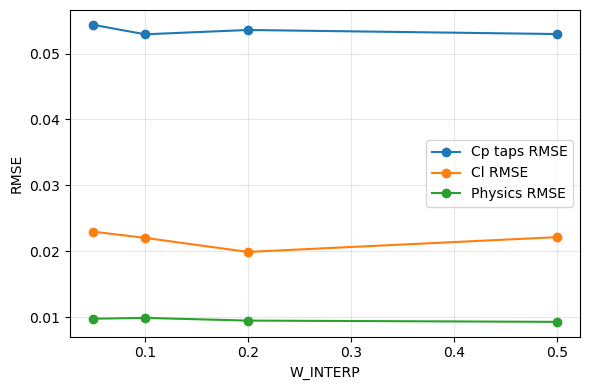

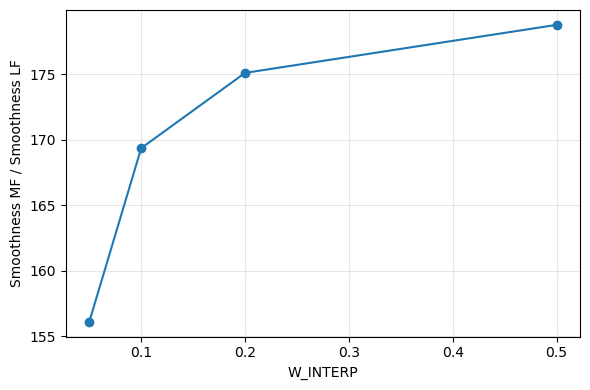

In [4]:
# ============================================================
# 0. Imports
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import sklearn as skl
import joblib
import matplotlib.pyplot as plt

from scipy.interpolate import PchipInterpolator
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# 1. Configuration
# ============================================================

N_INPUTS = 3
N_CP = 201
N_TAPS = 31
N_OUTPUTS = N_CP + 1  # [Cl, Cp_1, ..., Cp_201]

L2_FACTOR = 1e-5

LAMBDA_PHYSICAL = 0.1
LAMBDA_SMOOTH = 0.001

W_CL = 0.2
W_TAP = 1.0

LEARNING_RATE = 1e-4
BATCH_SIZE = 32
EPOCHS = 5000

# Choose architecture:
# 'residual' or 'affine'
MODEL_TYPE = 'residual'

# Interpolation weights to test
W_INTERP_LIST = [0.05, 0.10, 0.20, 0.50]

# Affine mapping setting
ALPHA_LIMIT = 0.1

# Output folder
RESULTS_DIR = 'results_interp_tests'
os.makedirs(RESULTS_DIR, exist_ok=True)


# ============================================================
# 2. Paths
# ============================================================

AIRFOIL_PATH = 'utils/NACA23015.csv'
AOA_EFFECTIVE_PATH = 'utils/LowFidelity-AoAEffectiveData.csv'
HF_DATA_PATH = 'utils/HighFidelity-Aviation-PressureDistributionData.csv'
LF_CP_DATA_PATH = 'utils/LowFidelity-PressureDistributionData.csv'

X_SCALER_PATH = 'utils/mlp_ann_X_scaler.pkl'
Y_SCALER_PATH = 'utils/mlp_ann_y_scaler.pkl'
LF_MODEL_PATH = 'utils/MLP-ANN.keras'


# ============================================================
# 3. Load auxiliary data
# ============================================================

airfoil_data = pd.read_csv(
    AIRFOIL_PATH,
    sep=',',
    names=['x', 'y']
)

AoA_effective_data = pd.read_csv(
    AOA_EFFECTIVE_PATH,
    sep=';'
)

panel_dx = np.diff(airfoil_data['x'].values).astype(np.float32)
panel_dy = np.diff(airfoil_data['y'].values).astype(np.float32)

x_airfoil = airfoil_data['x'].values.astype(np.float32)
y_airfoil = airfoil_data['y'].values.astype(np.float32)

X_scaler = joblib.load(X_SCALER_PATH)
y_scaler = joblib.load(Y_SCALER_PATH)

with open(LF_CP_DATA_PATH, 'r', encoding='utf-8') as f:
    header = f.readline().strip()

headers = header.split(';')
x_cp_201 = np.array([float(col) for col in headers[4:]], dtype=np.float32)


# ============================================================
# 4. Tap indices
# ============================================================

tap_indices = np.array([
    8, 14, 21, 27, 33, 39, 45, 50, 55, 60,
    65, 71, 77, 84, 93, 103, 111, 119, 126,
    132, 137, 141, 145, 150, 156, 161, 167,
    173, 179, 186, 192
], dtype=np.int32)

x_cp_taps = x_cp_201[tap_indices]


# ============================================================
# 5. Utility functions
# ============================================================

def regression_metrics(y_true, y_pred, name=''):
    mse = mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    r2 = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

    return {
        'case': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }


def inverse_transform_full_output(y_scaled, y_scaler):
    """
    Inverse transform complete output:
        [Cl, Cp_1, ..., Cp_201]
    """

    return (
        y_scaled * y_scaler.scale_.reshape(1, -1)
        + y_scaler.mean_.reshape(1, -1)
    )


def inverse_transform_hf_targets_with_interp(y_hf_scaled, y_scaler, tap_indices):
    """
    Inverse transform sparse HF targets with interpolation.

    y_hf_scaled format:
        [Cl_scaled, Cp_taps_scaled_31, Cp_interp_scaled_201, AoA_raw]
    """

    cl_scaled = y_hf_scaled[:, :1]

    start_taps = 1
    end_taps = start_taps + N_TAPS

    start_interp = end_taps
    end_interp = start_interp + N_CP

    cp_taps_scaled = y_hf_scaled[:, start_taps:end_taps]
    cp_interp_scaled = y_hf_scaled[:, start_interp:end_interp]
    aoa_raw = y_hf_scaled[:, -1:]

    cl_raw = (
        cl_scaled * y_scaler.scale_[0]
        + y_scaler.mean_[0]
    )

    cp_tap_means = y_scaler.mean_[1:][tap_indices].reshape(1, -1)
    cp_tap_scales = y_scaler.scale_[1:][tap_indices].reshape(1, -1)

    cp_taps_raw = cp_taps_scaled * cp_tap_scales + cp_tap_means

    cp_interp_raw = (
        cp_interp_scaled * y_scaler.scale_[1:].reshape(1, -1)
        + y_scaler.mean_[1:].reshape(1, -1)
    )

    return cl_raw, cp_taps_raw, cp_interp_raw, aoa_raw


def integrate_cp_to_cl_numpy(cp_raw, aoa_deg, panel_dx, panel_dy):
    """
    Computes Cl by integrating Cp distribution using the same formulation
    used in the PINN loss.
    """

    panel_cp = 0.5 * (cp_raw[:, :-1] + cp_raw[:, 1:])

    cn = np.sum(
        panel_cp * panel_dx.reshape(1, -1),
        axis=1,
        keepdims=True
    )

    ca = -np.sum(
        panel_cp * panel_dy.reshape(1, -1),
        axis=1,
        keepdims=True
    )

    aoa_rad = aoa_deg * np.pi / 180.0

    cl_from_cp = (
        cn * np.cos(aoa_rad)
        - ca * np.sin(aoa_rad)
    )

    return cl_from_cp


def cp_smoothness_metric(cp_raw):
    """
    Smoothness metric based on second finite difference.
    Lower values indicate smoother Cp distributions.
    """

    d2 = cp_raw[:, 2:] - 2.0 * cp_raw[:, 1:-1] + cp_raw[:, :-2]

    return np.mean(d2 ** 2)


def average_duplicate_x(x_values, y_values):
    """
    PCHIP requires strictly increasing x.
    This function averages y values for duplicated x coordinates.
    """

    df = pd.DataFrame({
        'x': x_values,
        'y': y_values
    })

    df = df.groupby('x', as_index=False)['y'].mean()
    df = df.sort_values('x')

    return df['x'].to_numpy(), df['y'].to_numpy()


# ============================================================
# 6. PCHIP interpolation by airfoil surface
# ============================================================

def interpolate_cp_by_surface(
    cp_taps_raw,
    x_airfoil,
    y_airfoil,
    tap_indices
):
    """
    Interpolates sparse Cp taps to the full 201-point airfoil grid using PCHIP.

    The interpolation is performed separately on upper and lower surfaces
    to avoid mixing pressure values from both surfaces at similar x/c.

    Parameters
    ----------
    cp_taps_raw : np.ndarray
        Shape: (n_samples, 31)

    x_airfoil : np.ndarray
        Shape: (201,)

    y_airfoil : np.ndarray
        Shape: (201,)

    tap_indices : np.ndarray
        Indices of the 31 taps within the 201-point Cp grid.

    Returns
    -------
    cp_interp_raw : np.ndarray
        Shape: (n_samples, 201)
    """

    tap_indices = np.asarray(tap_indices, dtype=int)

    upper_full_idx = np.where(y_airfoil >= 0.0)[0]
    lower_full_idx = np.where(y_airfoil < 0.0)[0]

    upper_tap_positions = np.where(y_airfoil[tap_indices] >= 0.0)[0]
    lower_tap_positions = np.where(y_airfoil[tap_indices] < 0.0)[0]

    upper_tap_idx_full = tap_indices[upper_tap_positions]
    lower_tap_idx_full = tap_indices[lower_tap_positions]

    if len(upper_tap_idx_full) < 2:
        raise ValueError('Upper surface has fewer than 2 taps.')

    if len(lower_tap_idx_full) < 2:
        raise ValueError('Lower surface has fewer than 2 taps.')

    cp_interp_all = np.zeros(
        (cp_taps_raw.shape[0], len(x_airfoil)),
        dtype=np.float32
    )

    x_upper_full = x_airfoil[upper_full_idx]
    x_lower_full = x_airfoil[lower_full_idx]

    x_upper_taps = x_airfoil[upper_tap_idx_full]
    x_lower_taps = x_airfoil[lower_tap_idx_full]

    sort_upper_full = np.argsort(x_upper_full)
    sort_lower_full = np.argsort(x_lower_full)

    for i, cp_row in enumerate(cp_taps_raw):

        cp_upper_taps = cp_row[upper_tap_positions]
        cp_lower_taps = cp_row[lower_tap_positions]

        # -----------------------------
        # Upper surface interpolation
        # -----------------------------

        x_u_unique, cp_u_unique = average_duplicate_x(
            x_upper_taps,
            cp_upper_taps
        )

        pchip_upper = PchipInterpolator(
            x_u_unique,
            cp_u_unique,
            extrapolate=True
        )

        cp_upper_interp_sorted = pchip_upper(
            x_upper_full[sort_upper_full]
        )

        cp_interp_all[i, upper_full_idx[sort_upper_full]] = cp_upper_interp_sorted

        # -----------------------------
        # Lower surface interpolation
        # -----------------------------

        x_l_unique, cp_l_unique = average_duplicate_x(
            x_lower_taps,
            cp_lower_taps
        )

        pchip_lower = PchipInterpolator(
            x_l_unique,
            cp_l_unique,
            extrapolate=True
        )

        cp_lower_interp_sorted = pchip_lower(
            x_lower_full[sort_lower_full]
        )

        cp_interp_all[i, lower_full_idx[sort_lower_full]] = cp_lower_interp_sorted

    return cp_interp_all.astype(np.float32)


# ============================================================
# 7. Effective AoA matching
# ============================================================

def match_effective_angle_cases(data, AoA_effective_data):
    """
    Matches each high-fidelity case with the closest low-fidelity
    effective angle of attack case using standardized Euclidean distance.

    Matching variables:
        Re, AoA, y
    """

    required_cols = ['Re', 'AoA', 'y', 'AoA_Effective']

    AoA_effective_data = AoA_effective_data[required_cols].dropna().copy()

    hf_cases = data[['Re', 'AoA', 'y']].to_numpy(dtype=np.float64)
    lf_cases = AoA_effective_data[['Re', 'AoA', 'y']].to_numpy(dtype=np.float64)

    std_values = AoA_effective_data[['Re', 'AoA', 'y']].std().to_numpy(dtype=np.float64)

    if np.any(std_values == 0):
        raise ValueError('At least one matching variable has zero standard deviation.')

    AoA_effective_values = AoA_effective_data['AoA_Effective'].to_numpy(dtype=np.float64)

    matched_AoA_effective = []

    for case in hf_cases:
        distance = np.sqrt(
            ((lf_cases[:, 0] - case[0]) / std_values[0]) ** 2 +
            ((lf_cases[:, 1] - case[1]) / std_values[1]) ** 2 +
            ((lf_cases[:, 2] - case[2]) / std_values[2]) ** 2
        )

        closest_idx = np.argmin(distance)
        matched_AoA_effective.append(AoA_effective_values[closest_idx])

    matched_AoA_effective = np.array(matched_AoA_effective, dtype=np.float32)

    if not np.all(np.isfinite(matched_AoA_effective)):
        raise ValueError('Matched AoA_Effective contains NaN or inf.')

    return matched_AoA_effective


# ============================================================
# 8. Load and split data
# ============================================================

def load_and_split_data(filepath, AoA_effective_data):
    """
    Loads high-fidelity data, adds AoA_Effective, and splits into
    train/validation/test sets.
    """

    data = pd.read_csv(filepath, sep=';').copy()

    data['AoA_Effective'] = match_effective_angle_cases(
        data=data,
        AoA_effective_data=AoA_effective_data
    )

    if data['AoA_Effective'].isna().any():
        raise ValueError('AoA_Effective contains NaN values.')

    # Current split: each row is treated as one case
    wing_sections = 1

    idx = np.arange(len(data))
    data['flow_case'] = idx // wing_sections

    unique_cases = data['flow_case'].unique()

    train_cases, test_cases = skl.model_selection.train_test_split(
        unique_cases,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    train_cases, val_cases = skl.model_selection.train_test_split(
        train_cases,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    data_train = data[data['flow_case'].isin(train_cases)].copy()
    data_val = data[data['flow_case'].isin(val_cases)].copy()
    data_test = data[data['flow_case'].isin(test_cases)].copy()

    return data_train, data_val, data_test


# ============================================================
# 9. Preprocess data with interpolated Cp pseudo-labels
# ============================================================

def preprocess_data_with_interp(
    data_train,
    data_val,
    data_test,
    X_scaler,
    y_scaler,
    tap_indices,
    x_airfoil,
    y_airfoil
):
    """
    Preprocesses high-fidelity data for MF-PINN with interpolated Cp.

    X format:
        [Re, AoA, y]

    Raw y format:
        [cl, Cp_1, ..., Cp_31]

    Final y format:
        [cl_scaled,
         Cp_taps_scaled_31,
         Cp_interp_scaled_201,
         AoA_Effective_raw]
    """

    tap_indices = np.asarray(tap_indices, dtype=int)

    X_cols = ['Re', 'AoA', 'y']

    y_cols = (
        ['cl']
        + [
            col for col in data_train.columns[4:]
            if col not in ['AoA_Effective', 'flow_case']
        ]
    )

    # -----------------------------
    # Raw arrays
    # -----------------------------

    X_train_raw = data_train[X_cols].to_numpy(dtype=np.float32)
    X_val_raw = data_val[X_cols].to_numpy(dtype=np.float32)
    X_test_raw = data_test[X_cols].to_numpy(dtype=np.float32)

    AoA_train_raw = data_train[['AoA_Effective']].to_numpy(dtype=np.float32)
    AoA_val_raw = data_val[['AoA_Effective']].to_numpy(dtype=np.float32)
    AoA_test_raw = data_test[['AoA_Effective']].to_numpy(dtype=np.float32)

    y_train_raw = data_train[y_cols].to_numpy(dtype=np.float32)
    y_val_raw = data_val[y_cols].to_numpy(dtype=np.float32)
    y_test_raw = data_test[y_cols].to_numpy(dtype=np.float32)

    # -----------------------------
    # Input scaling
    # -----------------------------

    X_train = X_scaler.transform(X_train_raw).astype(np.float32)
    X_val = X_scaler.transform(X_val_raw).astype(np.float32)
    X_test = X_scaler.transform(X_test_raw).astype(np.float32)

    # -----------------------------
    # Target scaling with interpolation
    # -----------------------------

    def scale_hf_targets_with_interp(y_raw, AoA_raw):
        cl_raw = y_raw[:, :1]
        cp_taps_raw = y_raw[:, 1:]

        # Cl scaling
        cl_mean = y_scaler.mean_[0]
        cl_scale = y_scaler.scale_[0]

        cl_scaled = (cl_raw - cl_mean) / cl_scale

        # Sparse tap scaling
        cp_tap_means = y_scaler.mean_[1:][tap_indices].reshape(1, -1)
        cp_tap_scales = y_scaler.scale_[1:][tap_indices].reshape(1, -1)

        cp_taps_scaled = (
            cp_taps_raw - cp_tap_means
        ) / cp_tap_scales

        # Interpolated Cp in raw units
        cp_interp_raw = interpolate_cp_by_surface(
            cp_taps_raw=cp_taps_raw,
            x_airfoil=x_airfoil,
            y_airfoil=y_airfoil,
            tap_indices=tap_indices
        )

        # Full Cp interpolation scaling
        cp_interp_scaled = (
            cp_interp_raw - y_scaler.mean_[1:].reshape(1, -1)
        ) / y_scaler.scale_[1:].reshape(1, -1)

        y_final = np.hstack((
            cl_scaled,
            cp_taps_scaled,
            cp_interp_scaled,
            AoA_raw
        )).astype(np.float32)

        return y_final

    y_train = scale_hf_targets_with_interp(y_train_raw, AoA_train_raw)
    y_val = scale_hf_targets_with_interp(y_val_raw, AoA_val_raw)
    y_test = scale_hf_targets_with_interp(y_test_raw, AoA_test_raw)

    arrays_to_check = {
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
    }

    for name, array in arrays_to_check.items():
        if not np.all(np.isfinite(array)):
            raise ValueError(f'{name} contains NaN or inf.')

    print('X_train:', X_train.shape)
    print('y_train:', y_train.shape)
    print('X_val:', X_val.shape)
    print('y_val:', y_val.shape)
    print('X_test:', X_test.shape)
    print('y_test:', y_test.shape)

    return X_train, y_train, X_val, y_val, X_test, y_test


# ============================================================
# 10. Model architectures
# ============================================================

def build_residual_multifidelity_model(lf_model, l2_factor=1e-5):
    """
    Residual MF model:
        y_MF = y_LF + delta
    """

    inputs = keras.Input(shape=(N_INPUTS,), name='inputs')

    lf_outputs = lf_model(inputs)

    correction_input = keras.layers.Concatenate(name='correction_input')(
        [inputs, lf_outputs]
    )

    regularizer = keras.regularizers.l2(l2_factor)

    x = keras.layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizer,
        name='corr_dense_1'
    )(correction_input)

    x = keras.layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizer,
        name='corr_dense_2'
    )(x)

    x = keras.layers.Dense(
        64,
        activation='swish',
        kernel_regularizer=regularizer,
        name='corr_dense_3'
    )(x)

    delta_outputs = keras.layers.Dense(
        N_OUTPUTS,
        activation='linear',
        kernel_initializer='zeros',
        bias_initializer='zeros',
        kernel_regularizer=regularizer,
        name='delta_outputs'
    )(x)

    mf_outputs = keras.layers.Add(name='outputs')(
        [lf_outputs, delta_outputs]
    )

    model = keras.Model(
        inputs=inputs,
        outputs=mf_outputs,
        name='residual_mf_pinn_with_interp'
    )

    return model


def build_affine_multifidelity_model(lf_model, l2_factor=1e-5, alpha_limit=0.1):
    """
    Affine MF model:
        y_MF = (1 + alpha) * y_LF + beta
    """

    inputs = keras.Input(shape=(N_INPUTS,), name='inputs')

    lf_outputs = lf_model(inputs)

    correction_input = keras.layers.Concatenate(name='correction_input')(
        [inputs, lf_outputs]
    )

    regularizer = keras.regularizers.l2(l2_factor)

    x = keras.layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizer,
        name='corr_dense_1'
    )(correction_input)

    x = keras.layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizer,
        name='corr_dense_2'
    )(x)

    x = keras.layers.Dense(
        64,
        activation='swish',
        kernel_regularizer=regularizer,
        name='corr_dense_3'
    )(x)

    affine_outputs = keras.layers.Dense(
        2 * N_OUTPUTS,
        activation='linear',
        kernel_initializer='zeros',
        bias_initializer='zeros',
        kernel_regularizer=regularizer,
        name='affine_outputs'
    )(x)

    alpha_raw = keras.layers.Lambda(
        lambda t: t[:, :N_OUTPUTS],
        name='alpha_raw'
    )(affine_outputs)

    beta = keras.layers.Lambda(
        lambda t: t[:, N_OUTPUTS:],
        name='beta'
    )(affine_outputs)

    alpha = keras.layers.Lambda(
        lambda t: alpha_limit * tf.tanh(t),
        name='alpha_limited'
    )(alpha_raw)

    one_plus_alpha = keras.layers.Lambda(
        lambda t: 1.0 + t,
        name='one_plus_alpha'
    )(alpha)

    scaled_lf = keras.layers.Multiply(name='scaled_lf')(
        [one_plus_alpha, lf_outputs]
    )

    mf_outputs = keras.layers.Add(name='outputs')(
        [scaled_lf, beta]
    )

    model = keras.Model(
        inputs=inputs,
        outputs=mf_outputs,
        name='affine_mf_pinn_with_interp'
    )

    return model


# ============================================================
# 11. Loss with interpolation pseudo-label
# ============================================================

def build_mf_pinn_loss_with_interp(
    panel_dx,
    panel_dy,
    tap_indices,
    lambda_physical,
    lambda_smooth,
    w_cl,
    w_tap,
    w_interp,
    y_scaler
):
    """
    MF-PINN loss with interpolated Cp pseudo-label.

    y_true format:
        [Cl_scaled,
         Cp_taps_scaled_31,
         Cp_interp_scaled_201,
         AoA_Effective_raw]

    y_pred format:
        [Cl_pred_scaled,
         Cp_pred_scaled_201]
    """

    panel_dx = tf.constant(panel_dx, dtype=tf.float32)
    panel_dy = tf.constant(panel_dy, dtype=tf.float32)
    tap_indices = tf.constant(tap_indices, dtype=tf.int32)

    y_mean = y_scaler.mean_.astype(np.float32)
    y_scale = y_scaler.scale_.astype(np.float32)

    Cl_mean = tf.constant(y_mean[0:1].reshape(1, 1), dtype=tf.float32)
    Cl_scale = tf.constant(y_scale[0:1].reshape(1, 1), dtype=tf.float32)

    Cp_mean = tf.constant(y_mean[1:].reshape(1, -1), dtype=tf.float32)
    Cp_scale = tf.constant(y_scale[1:].reshape(1, -1), dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, dtype=tf.float32)
        y_pred = tf.cast(y_pred, dtype=tf.float32)

        # -----------------------------
        # Extract y_true
        # -----------------------------

        Cl_true = y_true[:, 0:1]

        start_taps = 1
        end_taps = start_taps + N_TAPS

        start_interp = end_taps
        end_interp = start_interp + N_CP

        Cp_true_taps = y_true[:, start_taps:end_taps]
        Cp_interp = y_true[:, start_interp:end_interp]
        AoA_deg = y_true[:, -1:]

        # -----------------------------
        # Extract y_pred
        # -----------------------------

        Cl_pred = y_pred[:, 0:1]
        Cp_pred = y_pred[:, 1:]

        Cp_pred_taps = tf.gather(
            Cp_pred,
            tap_indices,
            axis=1
        )

        # -----------------------------
        # Supervised losses in scaled space
        # -----------------------------

        cl_loss = tf.reduce_mean(
            tf.square(Cl_true - Cl_pred)
        )

        tap_loss = tf.reduce_mean(
            tf.square(Cp_true_taps - Cp_pred_taps)
        )

        interp_loss = tf.reduce_mean(
            tf.square(Cp_interp - Cp_pred)
        )

        # -----------------------------
        # Rescale predictions to physical units
        # -----------------------------

        Cl_pred_raw = Cl_pred * Cl_scale + Cl_mean
        Cp_pred_raw = Cp_pred * Cp_scale + Cp_mean

        # -----------------------------
        # Physics-informed loss
        # -----------------------------

        panel_Cp = 0.5 * (
            Cp_pred_raw[:, :-1] + Cp_pred_raw[:, 1:]
        )

        Cn = tf.reduce_sum(
            panel_Cp * panel_dx,
            axis=1,
            keepdims=True
        )

        Ca = -tf.reduce_sum(
            panel_Cp * panel_dy,
            axis=1,
            keepdims=True
        )

        AoA_rad = AoA_deg * (np.pi / 180.0)

        Cl_from_Cp_raw = (
            Cn * tf.cos(AoA_rad)
            - Ca * tf.sin(AoA_rad)
        )

        physical_loss = tf.reduce_mean(
            tf.square(Cl_pred_raw - Cl_from_Cp_raw)
        )

        # -----------------------------
        # Smoothness loss in physical units
        # -----------------------------

        d2Cp = (
            Cp_pred_raw[:, 2:]
            - 2.0 * Cp_pred_raw[:, 1:-1]
            + Cp_pred_raw[:, :-2]
        )

        smooth_loss = tf.reduce_mean(
            tf.square(d2Cp)
        )

        # -----------------------------
        # Total loss
        # -----------------------------

        loss = (
            w_tap * tap_loss
            + w_interp * interp_loss
            + w_cl * cl_loss
            + lambda_physical * physical_loss
            + lambda_smooth * smooth_loss
        )

        return loss

    return loss_fn


# ============================================================
# 12. Load data once
# ============================================================

data_train, data_val, data_test = load_and_split_data(
    filepath=HF_DATA_PATH,
    AoA_effective_data=AoA_effective_data
)

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data_with_interp(
    data_train=data_train,
    data_val=data_val,
    data_test=data_test,
    X_scaler=X_scaler,
    y_scaler=y_scaler,
    tap_indices=tap_indices,
    x_airfoil=x_airfoil,
    y_airfoil=y_airfoil
)


# ============================================================
# 13. Train/evaluate one model
# ============================================================

def train_and_evaluate_interp_model(w_interp, model_type='residual'):
    """
    Trains and evaluates one MF-PINN model with a given interpolation weight.
    """

    print('\n' + '=' * 70)
    print(f'Training model_type={model_type}, W_INTERP={w_interp}')
    print('=' * 70)

    keras.backend.clear_session()

    lf_model = keras.models.load_model(
        LF_MODEL_PATH,
        compile=False
    )

    lf_model.trainable = False

    if model_type == 'residual':
        mf_model = build_residual_multifidelity_model(
            lf_model=lf_model,
            l2_factor=L2_FACTOR
        )

    elif model_type == 'affine':
        mf_model = build_affine_multifidelity_model(
            lf_model=lf_model,
            l2_factor=L2_FACTOR,
            alpha_limit=ALPHA_LIMIT
        )

    else:
        raise ValueError("model_type must be 'residual' or 'affine'.")

    loss_fn = build_mf_pinn_loss_with_interp(
        panel_dx=panel_dx,
        panel_dy=panel_dy,
        tap_indices=tap_indices,
        lambda_physical=LAMBDA_PHYSICAL,
        lambda_smooth=LAMBDA_SMOOTH,
        w_cl=W_CL,
        w_tap=W_TAP,
        w_interp=w_interp,
        y_scaler=y_scaler
    )

    mf_model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE,
            clipnorm=1.0
        ),
        loss=loss_fn
    )

    callbacks = [
        keras.callbacks.TerminateOnNaN(),

        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=30,
            min_delta=1e-6,
            restore_best_weights=True
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            cooldown=5,
            min_delta=1e-5,
            min_lr=1e-7
        )
    ]

    history = mf_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    # -----------------------------
    # Predictions
    # -----------------------------

    pred_test = mf_model.predict(X_test)
    lf_test = lf_model.predict(X_test)

    pred_test_raw = inverse_transform_full_output(pred_test, y_scaler)
    lf_test_raw = inverse_transform_full_output(lf_test, y_scaler)

    cl_test_pred_raw = pred_test_raw[:, :1]
    cp_test_pred_raw = pred_test_raw[:, 1:]

    cl_lf_test_raw = lf_test_raw[:, :1]
    cp_lf_test_raw = lf_test_raw[:, 1:]

    cl_test_true_raw, cp_test_true_taps_raw, cp_interp_test_raw, aoa_test_eff_raw = (
        inverse_transform_hf_targets_with_interp(
            y_test,
            y_scaler,
            tap_indices
        )
    )

    cp_test_pred_taps_raw = cp_test_pred_raw[:, tap_indices]
    cp_lf_test_taps_raw = cp_lf_test_raw[:, tap_indices]

    # -----------------------------
    # Physics consistency
    # -----------------------------

    cl_test_from_cp_raw = integrate_cp_to_cl_numpy(
        cp_test_pred_raw,
        aoa_test_eff_raw,
        panel_dx,
        panel_dy
    )

    # -----------------------------
    # Metrics
    # -----------------------------

    cp_metrics = regression_metrics(
        cp_test_true_taps_raw,
        cp_test_pred_taps_raw,
        'MF Cp taps raw'
    )

    cl_metrics = regression_metrics(
        cl_test_true_raw,
        cl_test_pred_raw,
        'MF Cl raw'
    )

    physics_metrics = regression_metrics(
        cl_test_pred_raw,
        cl_test_from_cp_raw,
        'MF Cl predicted vs integrated'
    )

    interp_metrics = regression_metrics(
        cp_interp_test_raw,
        cp_test_pred_raw,
        'MF Cp full vs PCHIP interp'
    )

    lf_cp_metrics = regression_metrics(
        cp_test_true_taps_raw,
        cp_lf_test_taps_raw,
        'LF Cp taps raw'
    )

    lf_cl_metrics = regression_metrics(
        cl_test_true_raw,
        cl_lf_test_raw,
        'LF Cl raw'
    )

    smooth_lf = cp_smoothness_metric(cp_lf_test_raw)
    smooth_mf = cp_smoothness_metric(cp_test_pred_raw)
    smooth_interp = cp_smoothness_metric(cp_interp_test_raw)

    result = {
        'model_type': model_type,
        'w_interp': w_interp,

        'epochs_trained': len(history.history['loss']),
        'final_loss': history.history['loss'][-1],
        'final_val_loss': history.history['val_loss'][-1],

        'LF_Cp_RMSE': lf_cp_metrics['RMSE'],
        'MF_Cp_RMSE': cp_metrics['RMSE'],
        'LF_Cp_MAE': lf_cp_metrics['MAE'],
        'MF_Cp_MAE': cp_metrics['MAE'],
        'MF_Cp_R2': cp_metrics['R2'],

        'LF_Cl_RMSE': lf_cl_metrics['RMSE'],
        'MF_Cl_RMSE': cl_metrics['RMSE'],
        'LF_Cl_MAE': lf_cl_metrics['MAE'],
        'MF_Cl_MAE': cl_metrics['MAE'],
        'MF_Cl_R2': cl_metrics['R2'],

        'Physics_RMSE': physics_metrics['RMSE'],
        'Physics_MAE': physics_metrics['MAE'],
        'Physics_R2': physics_metrics['R2'],

        'Interp_FullCp_RMSE': interp_metrics['RMSE'],
        'Interp_FullCp_MAE': interp_metrics['MAE'],

        'Smoothness_LF': smooth_lf,
        'Smoothness_MF': smooth_mf,
        'Smoothness_Interp': smooth_interp,
        'Smoothness_MF_over_LF': smooth_mf / smooth_lf,
    }

    # -----------------------------
    # Save model and history
    # -----------------------------

    model_name = f'{model_type}_interp_w{w_interp}'.replace('.', 'p')

    mf_model.save(
        os.path.join(RESULTS_DIR, f'{model_name}.keras')
    )

    history_df = pd.DataFrame(history.history)
    history_df.to_csv(
        os.path.join(RESULTS_DIR, f'{model_name}_history.csv'),
        index=False
    )

    # -----------------------------
    # Save plots for selected cases
    # -----------------------------

    selected_cases = [0, 5, 10, 20, 30]

    for i in selected_cases:
        plt.figure(figsize=(6, 4))

        plt.plot(
            x_cp_201,
            cp_lf_test_raw[i],
            label='Low-fidelity ANN',
            linewidth=1.5
        )

        plt.plot(
            x_cp_201,
            cp_interp_test_raw[i],
            label='PCHIP pseudo-HF',
            linewidth=1.2,
            linestyle='--'
        )

        plt.plot(
            x_cp_201,
            cp_test_pred_raw[i],
            label='MF-PINN',
            linewidth=1.5
        )

        plt.scatter(
            x_cp_taps,
            cp_test_true_taps_raw[i],
            label='HF taps',
            s=25
        )

        plt.gca().invert_yaxis()
        plt.xlabel('x/c')
        plt.ylabel('Cp')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plt.savefig(
            os.path.join(RESULTS_DIR, f'{model_name}_case_{i}.png'),
            dpi=300
        )

        plt.close()

    # -----------------------------
    # Save scatter plots
    # -----------------------------

    plt.figure(figsize=(5, 5))
    plt.scatter(
        cp_test_true_taps_raw.reshape(-1),
        cp_test_pred_taps_raw.reshape(-1),
        s=8,
        alpha=0.5
    )

    min_val = min(cp_test_true_taps_raw.min(), cp_test_pred_taps_raw.min())
    max_val = max(cp_test_true_taps_raw.max(), cp_test_pred_taps_raw.max())

    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    plt.xlabel('Experimental Cp at taps')
    plt.ylabel('Predicted MF Cp at taps')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        os.path.join(RESULTS_DIR, f'{model_name}_scatter_cp_taps.png'),
        dpi=300
    )
    plt.close()

    plt.figure(figsize=(5, 5))
    plt.scatter(
        cl_test_pred_raw.reshape(-1),
        cl_test_from_cp_raw.reshape(-1),
        s=12,
        alpha=0.6
    )

    min_val = min(cl_test_pred_raw.min(), cl_test_from_cp_raw.min())
    max_val = max(cl_test_pred_raw.max(), cl_test_from_cp_raw.max())

    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    plt.xlabel('Predicted Cl')
    plt.ylabel('Integrated Cl from predicted Cp')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        os.path.join(RESULTS_DIR, f'{model_name}_scatter_physics.png'),
        dpi=300
    )
    plt.close()

    return result


# ============================================================
# 14. Run interpolation weight tests
# ============================================================

all_results = []

for w_interp in W_INTERP_LIST:
    result = train_and_evaluate_interp_model(
        w_interp=w_interp,
        model_type=MODEL_TYPE
    )

    all_results.append(result)

results_df = pd.DataFrame(all_results)

results_df.to_csv(
    os.path.join(RESULTS_DIR, f'{MODEL_TYPE}_interp_summary.csv'),
    index=False
)

print('\n' + '=' * 70)
print('SUMMARY')
print('=' * 70)
print(results_df)


# ============================================================
# 15. Optional: plot summary metrics
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(results_df['w_interp'], results_df['MF_Cp_RMSE'], marker='o', label='Cp taps RMSE')
plt.plot(results_df['w_interp'], results_df['MF_Cl_RMSE'], marker='o', label='Cl RMSE')
plt.plot(results_df['w_interp'], results_df['Physics_RMSE'], marker='o', label='Physics RMSE')
plt.xlabel('W_INTERP')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, f'{MODEL_TYPE}_interp_rmse_summary.png'),
    dpi=300
)
plt.show()


plt.figure(figsize=(6, 4))
plt.plot(results_df['w_interp'], results_df['Smoothness_MF_over_LF'], marker='o')
plt.xlabel('W_INTERP')
plt.ylabel('Smoothness MF / Smoothness LF')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, f'{MODEL_TYPE}_interp_smoothness_summary.png'),
    dpi=300
)
plt.show()